# CardioIA — Fase 1 | Carregamento e verificação rápida dos dados

Notebook inicial que **carrega os três conjuntos de dados** da Fase 1 e confirma que
estão prontos para uso nas próximas fases (ML, NLP e Visão Computacional).

- Parte 1 — `dados/numericos/cardioia_heart_disease.csv`
- Parte 2 — `assets/textos/*.txt`
- Parte 3 — `dados/visuais/ecg_images/*.png` + `labels.csv`

> Rode a partir da pasta `notebooks/` (local) ou ajuste `BASE` para a raiz do
> repositório se estiver no Google Colab.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NUM = BASE / "dados" / "numericos"
TXT = BASE / "assets" / "textos"
VIS = BASE / "dados" / "visuais"
assert NUM.exists() and TXT.exists() and VIS.exists(), f"Ajuste BASE (atual: {BASE})"
print("raiz do repositório:", BASE)

raiz do repositório: /Users/gabrielcasarin/Documents/Fiap - AI and ML - Ano 2 - Fase 1/fiap-preparando-terreno-para-inteligencia-cardiologica


## Parte 1 — Dados numéricos (ML / IoT)

In [2]:
df = pd.read_csv(NUM / "cardioia_heart_disease.csv")
print(f"{df.shape[0]} pacientes x {df.shape[1]} colunas")
print("\nAlvo (doenca_cardiaca):")
print(df["doenca_cardiaca"].value_counts(normalize=True).round(3).to_string())
print("\nPor sexo:")
print(df.groupby("sexo")["doenca_cardiaca"].mean().round(3).to_string())
df.head()

920 pacientes x 25 colunas

Alvo (doenca_cardiaca):
doenca_cardiaca
1    0.553
0    0.447

Por sexo:
sexo
feminino     0.258
masculino    0.632


,id_paciente,origem,age,sex,sexo,cp,tipo_dor_peito,trestbps,chol,fbs,...,angina_por_esforco,oldpeak,slope,inclinacao_st,ca,thal,cintilografia_talio,faixa_etaria,diagnostico_num,doenca_cardiaca
0,CLE-0001,cleveland,63.0,1,masculino,1,angina_tipica,145.0,233.0,1.0,...,nao,2.3,3.0,descendente,0.0,6.0,defeito_fixo,60-69,0,0
1,CLE-0002,cleveland,67.0,1,masculino,4,assintomatico,160.0,286.0,0.0,...,sim,1.5,2.0,plano,3.0,3.0,normal,60-69,2,1
2,CLE-0003,cleveland,67.0,1,masculino,4,assintomatico,120.0,229.0,0.0,...,sim,2.6,2.0,plano,2.0,7.0,defeito_reversivel,60-69,1,1
3,CLE-0004,cleveland,37.0,1,masculino,3,dor_nao_anginosa,130.0,250.0,0.0,...,nao,3.5,3.0,descendente,0.0,3.0,normal,<40,0,0
4,CLE-0005,cleveland,41.0,0,feminino,2,angina_atipica,130.0,204.0,0.0,...,nao,1.4,1.0,ascendente,0.0,3.0,normal,40-49,0,0


## Parte 2 — Dados textuais (NLP)

In [3]:
def corpo(caminho: Path) -> str:
    """Retorna apenas o texto (descarta o cabeçalho METADADOS)."""
    bruto = caminho.read_text(encoding="utf-8")
    marcador = "=" * 78 + "\nTEXTO\n" + "=" * 78
    return bruto.split(marcador, 1)[-1].strip()


textos = sorted(TXT.glob("*.txt"))
for t in textos:
    c = corpo(t)
    print(f"{t.name:<55} {len(c.split()):>7} palavras")

print("\n--- trecho do texto 01 (OPAS/OMS) ---\n")
print(corpo(textos[0])[:600])

01_opas_oms_doencas_cardiovasculares_pt.txt                1689 palavras
02_scielo_abc_prevalencia_doencas_cardiacas_pt.txt         2678 palavras
03_gutenberg_lettsomian_lectures_diseases_heart_en.txt    21152 palavras
04_gutenberg_arteriosclerosis_and_hypertension_en.txt     67682 palavras

--- trecho do texto 01 (OPAS/OMS) ---

As doenças cardiovasculares são um grupo de doenças do coração e dos vasos sanguíneos e incluem:

- Doença coronariana – doença dos vasos sanguíneos que irrigam o músculo cardíaco; 
- Doença cerebrovascular – doença dos vasos sanguíneos que irrigam o cérebro; 
- Doença arterial periférica – doença dos vasos sanguíneos que irrigam os membros superiores e inferiores; 
- Doença cardíaca reumática – danos no músculo do coração e válvulas cardíacas devido à febre reumática, causada por bactérias estreptocócicas; 
- Cardiopatia congênita – malformações na estrutura do coração existentes desde o mome


## Parte 3 — Dados visuais (Visão Computacional)

In [4]:
labels = pd.read_csv(VIS / "labels.csv")
print(f"{len(labels)} imagens de ECG")
print("\nPor superclasse:")
print(labels["superclasse"].value_counts().to_string())
print("\nPor sexo:", dict(labels["sexo"].value_counts()))
labels.head()

120 imagens de ECG

Por superclasse:
superclasse
CD      24
HYP     24
MI      24
NORM    24
STTC    24

Por sexo: {'M': np.int64(60), 'F': np.int64(60)}


,arquivo,ecg_id,superclasse,superclasse_pt,scp_codes,idade,sexo,eixo_cardiaco,laudo_ptbxl
0,ecg_images/ECG_17722_CD.png,17722,CD,Disturbio de conducao,"{'IRBBB': 100.0, 'SARRH': 0.0}",10.0,M,NaN,sinus arrhythmia. incomplete right bundle bran...
1,ecg_images/ECG_10822_CD.png,10822,CD,Disturbio de conducao,"{'WPW': 50.0, 'SR': 0.0, 'SARRH': 0.0}",11.0,F,NaN,"sinus rhythm, with sinus arrhythmia.. wolff-pa..."
2,ecg_images/ECG_06849_CD.png,6849,CD,Disturbio de conducao,"{'IRBBB': 100.0, '1AVB': 100.0, 'SR': 0.0}",35.0,M,MID,sinusrhythmus a-v block i p-sinistrocardiale l...
3,ecg_images/ECG_17704_CD.png,17704,CD,Disturbio de conducao,"{'IRBBB': 100.0, 'SR': 0.0}",46.0,F,NaN,sinus rhythm. incomplete right bundle branch b...
4,ecg_images/ECG_14833_CD.png,14833,CD,Disturbio de conducao,"{'IVCD': 100.0, 'SBRAD': 0.0}",48.0,M,LAD,sinusbradykardie linkslagetyp intraventr. leit...


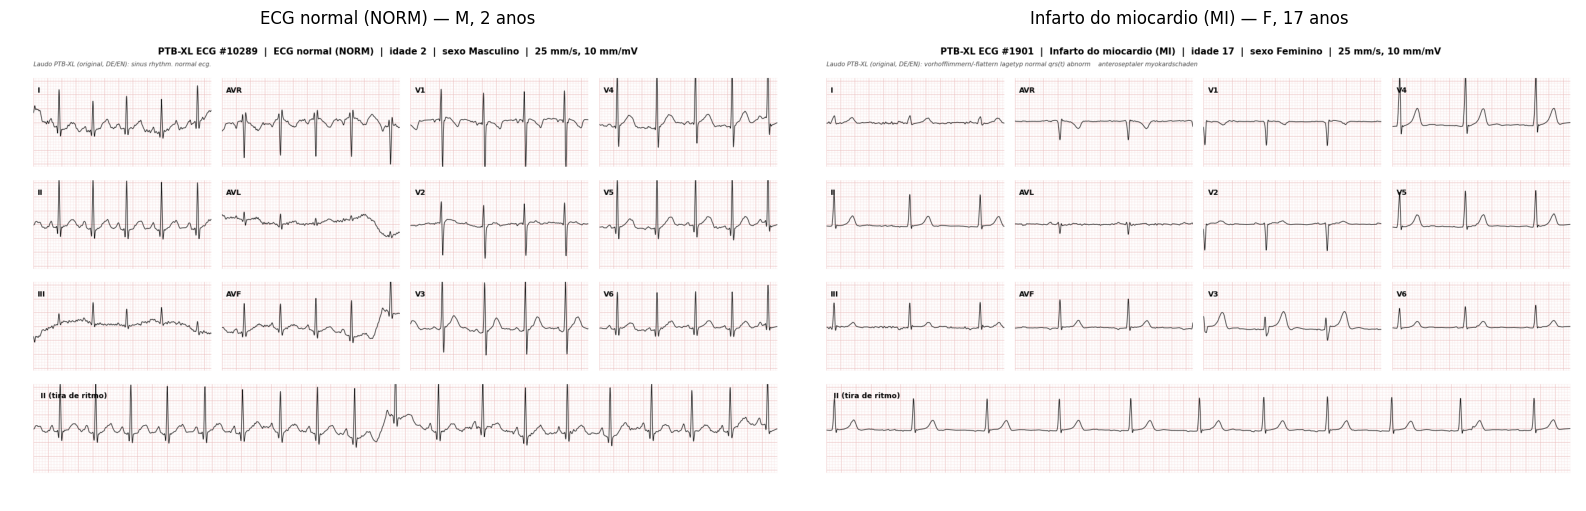

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, classe in zip(axes, ["NORM", "MI"]):
    linha = labels[labels["superclasse"] == classe].iloc[0]
    ax.imshow(mpimg.imread(VIS / linha["arquivo"]))
    ax.set_title(f"{linha['superclasse_pt']} ({classe}) — {linha['sexo']}, {int(linha['idade'])} anos")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Pronto para as próximas fases

- **Fase 2 (diagnóstico):** `df` → classificação supervisionada com alvo `doenca_cardiaca`
  (usar validação estratificada por `origem` e por `sexo` — ver `document/governanca-dados-e-vies.md`).
- **Fase 4 (imagem):** `labels.csv` → CNN `imagem → superclasse`.
- **Fases 2 e 5 (NLP):** o corpus de `assets/textos/` → extração de sintomas e RAG.